In [12]:
import os
if not os.path.exists("git/main.py"):
    !rm -rfd sample_data
    !rm -rfd git
    !git clone --single-branch --branch Util https://github.com/DemirDorukDilek/DDoP git


import importlib
import sys
top_level_container_dir = "git/"
if top_level_container_dir not in sys.path:
    sys.path.insert(0, top_level_container_dir)

import Utils,DDoPnDm
importlib.reload(Utils)
importlib.reload(DDoPnDm)
from Utils import visualize_trajectory_2d,polygon_to_polyhedron,visualize_state,visualize_results_2d
from DDoPnDm import DDoPnD

import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.optimize import minimize
import scipy.special

waypoints = [
    np.array((0, 0)), # q₀: Başlangıç
    np.array((1.5, 0.5)), # q₁: İlk dönüş
    np.array((2.5, 1.5)), # q₂: Engeli geç
    np.array((3.0, -1.5)), # q₃: İkinci dönüş
    np.array((5.25, 1.0)), # q₄: Bitiş
]

# Polyhedra: Her piece için güvenli bölge (CCW sıralı köşeler)
polygons = [
    # P₀: Başlangıç bölgesi (geniş alan)
    [
        (-0.5, -0.2),
        (1.6, 0.4),
        (1.6, 0.6),
        (-0.5, 0.2)
    ],

    # P₁: Dar geçit (engelin solundan)
    [
        (1.4, 0.4),
        (3.0, 1),
        (3.0, 2.5),
        (1.4, 0.6),
    ],

    # P₂: Engel üstü bölge
    [
        (2.4, 1.4),
        (3.0, -2),
        (4.0, -1.5),
        (2.4, 1.8)
    ],

    # P₃: Bitiş bölgesi
    [
        (2.9, -2),
        (5.5, -0.5),
        (5.5, 1.5),
        (2.9, -1.5)
    ],
]

[(np.int64(9), np.int64(0)), (np.int64(11), np.int64(-2)), (np.int64(12), np.int64(-1)), (np.int64(10), np.int64(1))]


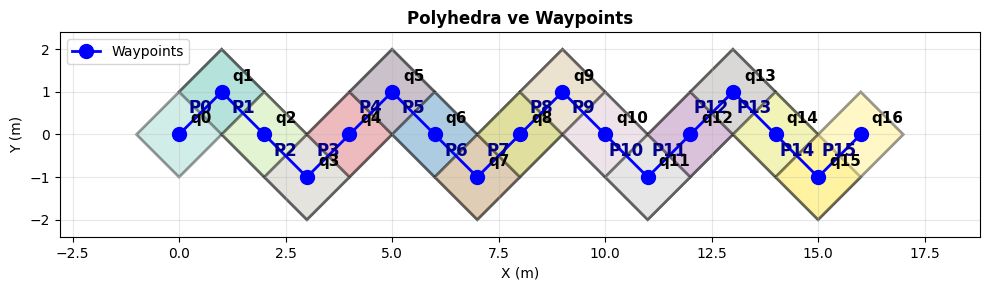

In [13]:
waypoints = [
    np.array((0, 0)),
    np.array((1, 1)),
    np.array((2, 0)),
    np.array((3, -1)),
    np.array((4, 0)),
    np.array((5, 1)),
    np.array((6, 0)),
    np.array((7, -1)),
    np.array((8, 0)),
    np.array((9, 1)),
    np.array((10, 0)),
    np.array((11, -1)),
    np.array((12, 0)),
    np.array((13, 1)),
    np.array((14, 0)),
    np.array((15, -1)),
    np.array((16, 0)),
]



d = 1
dd = True
polygons = []
for i in range(len(waypoints)-1):
    w0 = waypoints[i]
    w1 = waypoints[i+1]
    if dd:
        polygons.append([(w0[0],w0[1]-1),(w1[0]+1,w1[1]),(w1[0],w1[1]+1),(w0[0]-1,w0[1])])
    else:
        polygons.append([(w0[0]-1,w0[1]),(w1[0],w1[1]-1),(w1[0]+1,w1[1]),(w0[0],w0[1]+1)])
    if d == 1:
        dd = not dd
        d = -1
    d+=1
print(polygons[10])
opt_waypoint = list(map(np.array,waypoints))
polyhedras = list(map(polygon_to_polyhedron,polygons))
visualize_state(polyhedras,opt_waypoint)

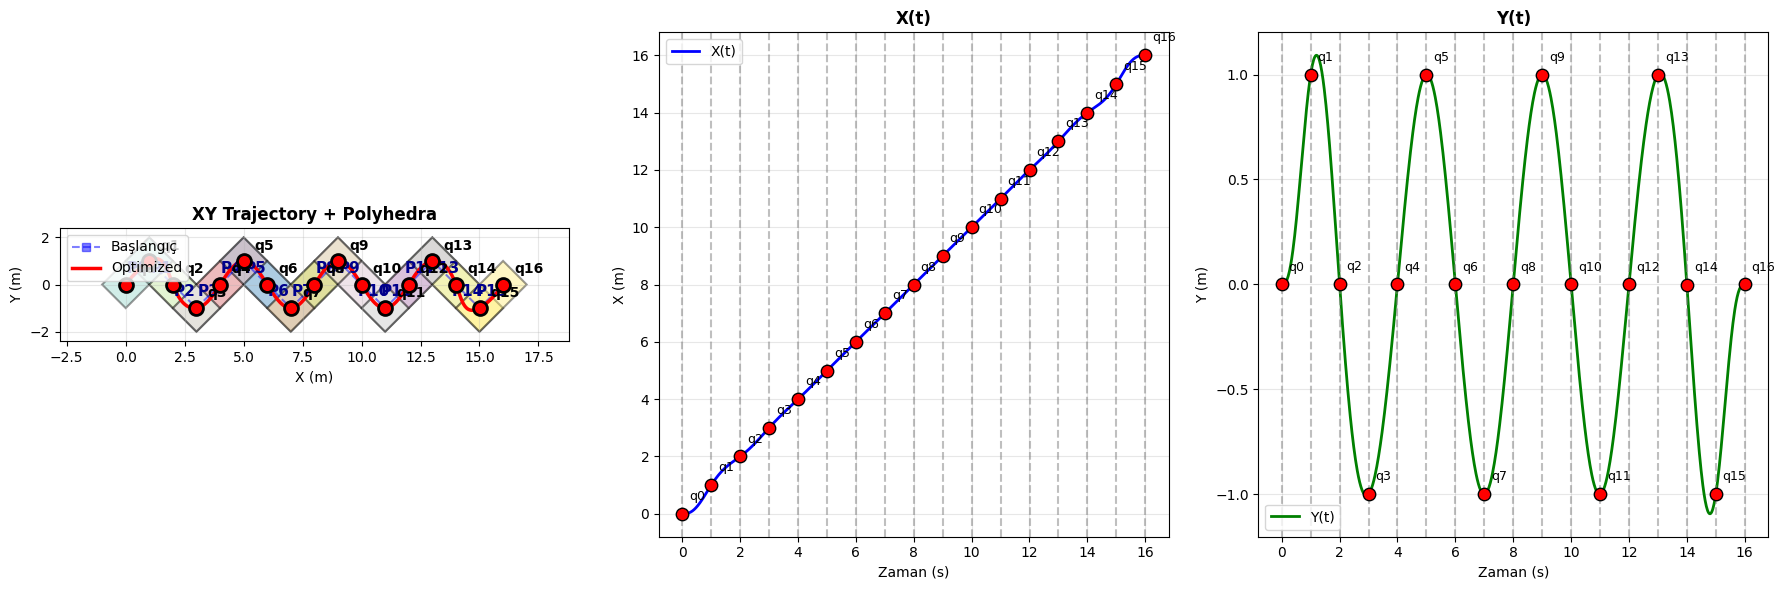

In [14]:
def check_piece_feasibility(opt, piece_idx, polyhedron, v_max, a_max, num_samples=50):
    T = opt.Ts[piece_idx]
    A, b = polyhedron
    S2 = 2 * opt.S

    c = np.array([subopt.Abs[piece_idx] @ subopt.dstar[2*opt.S*piece_idx : 2*opt.S*(piece_idx+1)].flatten() for subopt in opt.opt])

    dc = c[:, 1:] * np.arange(1, S2)
    ddc = dc[:, 1:] * np.arange(1, S2-1)

    t_powers = np.power(np.linspace(0, T, num_samples)[:, None], np.arange(S2))

    pos = t_powers @ c.T
    vel_mag = np.linalg.norm(t_powers[:,:S2-1] @ dc.T, axis=1)
    acc_mag = np.linalg.norm(t_powers[:,:S2-2] @ ddc.T, axis=1)

    slack = b - (A @ pos.T).T
    min_slack_per_sample = np.min(slack, axis=1)

    if np.any(slack < 0):
        return False,0

    if np.max(vel_mag) > v_max:
        return False,1

    if np.max(acc_mag) > a_max:
        return False,2

    return True,-1


def check_all_pieces(opt, polyhedrons, v_max, a_max, num_samples=50):
    violations = []
    for m in range(opt.M):
        poly_ok, type_ = check_piece_feasibility(opt, m, polyhedrons[m], v_max, a_max, num_samples)

        if not poly_ok:
            violations.append((m,type_))

    return violations


def split_polygon(polygon, q_prev, q_next, margin=0.1):
    q_prev = np.array(q_prev)
    q_next = np.array(q_next)

    midpoint = (q_prev + q_next) / 2
    direction = q_next - q_prev
    length = np.linalg.norm(direction)
    direction = direction / length

    plane0_point = midpoint - margin * direction
    plane1_point = midpoint + margin * direction

    poly_0 = clip_polygon_by_plane(polygon, plane0_point, direction)
    poly_1 = clip_polygon_by_plane(polygon, plane1_point, -direction)

    return poly_0, poly_1, midpoint


def clip_polygon_by_plane(polygon, plane_point, plane_normal):
    polygon = np.array(polygon)
    plane_point = np.array(plane_point)
    plane_normal = np.array(plane_normal)
    plane_normal = plane_normal / np.linalg.norm(plane_normal)

    clipped = []
    n = len(polygon)
    for i in range(n):
        curr = polygon[i]
        next_p = polygon[(i + 1) % n]

        d_curr = np.dot(curr - plane_point, plane_normal)
        d_next = np.dot(next_p - plane_point, plane_normal)

        if d_curr >= 0:
            clipped.append(curr)

        if d_curr * d_next < 0:
            t = d_curr / (d_curr - d_next)
            intersection = curr + t * (next_p - curr)
            clipped.append(intersection)

    if len(clipped) < 3:
        return polygon

    return clipped



def optimize_with_split(Ts_init, waypoints_init, polygons_init ,max_iterations=5):

    Ts = Ts_init.copy()
    waypoints = waypoints_init.copy()
    polygons = polygons_init.copy()
    rho_v = [128.0]*len(Ts)
    rho_a = [128.0]*len(Ts)
    pakka = [1.0]*len(Ts)
    last_split = -1
    for iteration in range(max_iterations):

        opt_waypoint = list(map(np.array,waypoints))
        polyhedras = list(map(polygon_to_polyhedron,polygons))
        rho_v_arr = np.array(rho_v)
        rho_a_arr = np.array(rho_a)
        pakka_arr = np.array(pakka)

        opt = DDoPnD([1.0]*(len(waypoints)-1),opt_waypoint,polyhedras,32.0,rho_v_arr,rho_a_arr,pakka_arr,False,False,3)
        T_opt, wp_opt, cost = opt.run()
        if "opt" in locals():
            visualize_results_2d(opt, polyhedras, wp_opt, [])
        # print(T_opt, wp_opt, cost)

        waypoints = [wp_opt[i] for i in range(len(wp_opt))]
        Ts = list(T_opt)

        violations = check_all_pieces(opt, polyhedras, opt.v_max, opt.a_max)[::-1]
        if len(violations) == 0:return opt, Ts, waypoints, polygons

        if len(violations) > 1 and violations[0][0] == last_split:
            piece_idx,vaolation_type = violations[1]
        else:
            piece_idx,vaolation_type = violations[0]
        last_split = piece_idx
        penalty_list = None

        print(piece_idx,vaolation_type)

        q_prev = waypoints[piece_idx]
        q_next = waypoints[piece_idx + 1]

        poly_0, poly_1,new_waypoint = split_polygon(polygons[piece_idx], q_prev, q_next, 0.5)

        waypoints.insert(piece_idx + 1, new_waypoint)
        Ts[piece_idx] = Ts[piece_idx] / 2
        Ts.insert(piece_idx + 1, Ts[piece_idx] / 2)

        if vaolation_type == 0:
            pakka[piece_idx] = pakka[piece_idx]*1.5
            pakka.insert(piece_idx + 1, pakka[piece_idx])
            rho_v.insert(piece_idx + 1,128.0)
            rho_a.insert(piece_idx + 1,128.0)
        elif vaolation_type == 1:
            rho_v[piece_idx] = rho_v[piece_idx]*1.5
            rho_v.insert(piece_idx + 1, rho_v[piece_idx])
            pakka.insert(piece_idx + 1,1.0)
            rho_a.insert(piece_idx + 1,128.0)
        elif vaolation_type == 2:
            rho_a[piece_idx] = rho_a[piece_idx]*1.5
            rho_a.insert(piece_idx + 1, rho_a[piece_idx])
            pakka.insert(piece_idx + 1,1.0)
            rho_v.insert(piece_idx + 1,128.0)

        polygons[piece_idx] = poly_1
        polygons.insert(piece_idx + 1, poly_0)


    return opt, Ts, waypoints, polygons

optimize_with_split([1.0]*(len(waypoints)-1),waypoints,polygons,10)
print()


In [18]:
"""
IRIS + Greedy Overlap Corridor Generation (2D, extensible to N-D)
"""

import numpy as np
import cvxpy as cp
from dataclasses import dataclass
from typing import List, Tuple, Optional


@dataclass
class ConvexObstacle:
    vertices: np.ndarray

    def get_edges(self):
        n = len(self.vertices)
        return [(self.vertices[i], self.vertices[(i + 1) % n]) for i in range(n)]


@dataclass
class HPolyhedron:
    A: np.ndarray
    b: np.ndarray

    def contains(self, point):
        return np.all(self.A @ point <= self.b + 1e-8)


@dataclass
class Ellipsoid:
    C: np.ndarray
    d: np.ndarray

    @property
    def volume(self):
        return abs(np.linalg.det(self.C))


@dataclass
class Corridor:
    hpoly: HPolyhedron
    ellipsoid: Ellipsoid
    seed: np.ndarray


def closest_point_on_vector(p, a, b):
    ab = b - a
    t = np.dot(p - a, ab) / (np.dot(ab, ab) + 1e-15)
    return a + np.clip(t, 0.0, 1.0) * ab


def closest_point_on_obstacle(point, obstacle):
    min_dist, nearest_point = np.inf, None
    for a, b in obstacle.get_edges():
        edge_point = closest_point_on_vector(point, a, b)
        d = np.linalg.norm(edge_point - point)
        if d < min_dist:
            min_dist, nearest_point = d, edge_point
    return nearest_point


def _compute_hyperplanes(center, obstacles, bounds):
    dim = len(center)
    A_rows, b_rows = [], []

    for obs in obstacles:
        p = closest_point_on_obstacle(center, obs)
        n = p - center
        if np.linalg.norm(n) < 1e-10:continue
        A_rows.append(n)
        b_rows.append(n @ p)

    for i in range(dim):
        e = np.zeros(dim); e[i] = 1.0
        A_rows.append(e.copy());  b_rows.append(bounds[1][i])
        A_rows.append(-e.copy()); b_rows.append(-bounds[0][i])

    return HPolyhedron(np.array(A_rows), np.array(b_rows))


def _max_ellipsoid(hpoly):
    A, b = hpoly.A, hpoly.b
    m, dim = A.shape
    C = cp.Variable((dim, dim), symmetric=True)
    d = cp.Variable(dim)
    constraints = [cp.norm(C @ A[i], 2) + A[i] @ d <= b[i] for i in range(m)]
    constraints.append(C >> 0)
    prob = cp.Problem(cp.Maximize(cp.log_det(C)), constraints)
    try:
        prob.solve(solver=cp.CLARABEL, verbose=False)
        if prob.status in ['optimal', 'optimal_inaccurate'] and C.value is not None:
            Cv = (C.value + C.value.T) / 2
            eigv = np.linalg.eigvalsh(Cv)
            Cv += max(0, -np.min(eigv) + 1e-8) * np.eye(dim)
            return Ellipsoid(Cv, d.value)
    except Exception:
        pass
    return None


def iris(seed, obstacles, bounds, max_iter=5, tol=1e-2):
    center = seed.copy()
    prev_vol = 0.0
    last_e = None

    for _ in range(max_iter):
        hpoly = _compute_hyperplanes(center, obstacles, bounds)
        e = _max_ellipsoid(hpoly)
        if e is None:
            break
        last_e = e
        center = e.d
        vol = e.volume
        if prev_vol > 0 and abs(vol - prev_vol) / (prev_vol + 1e-15) < tol:
            break
        prev_vol = vol

    if last_e is None:
        return None

    final_hpoly = _compute_hyperplanes(center, obstacles, bounds)
    return Corridor(final_hpoly, last_e, seed)


def greedy_corridor_generation(path, obstacles, bounds, max_corridors=30):
    corridors = []
    n = len(path)
    idx = 0

    while idx < n - 1 and len(corridors) < max_corridors:
        seed = path[idx].copy()
        if corridors:
            prev = corridors[-1]
            back_idx = max(0, idx - 1)
            if prev.hpoly.contains(path[back_idx]):
                seed = path[back_idx].copy()

        corridor = iris(seed, obstacles, bounds)
        if corridor is None:
            idx += 1
            continue

        corridors.append(corridor)

        next_idx = idx+1
        while next_idx < n - 1 and corridor.hpoly.contains(path[next_idx]):
            next_idx += 1
        if next_idx >= n:
            break
        idx = next_idx

    return corridors


def verify_corridors(corridors, path):
    ok = True
    for i in range(len(corridors) - 1):
        if not corridors[i].hpoly.contains(corridors[i + 1].seed):
            print(f"WARN: Corridor {i+1} seed not in corridor {i}")
            ok = False

    uncovered = sum(1 for pt in path if not any(c.hpoly.contains(pt) for c in corridors))
    if uncovered:
        print(f"{uncovered}/{len(path)} points uncovered")
        ok = False
    return ok


Path: 72 points
Generated 4 corridors
  All 72 points covered!

Corridor 0: seed=[1. 5.], center=[1.18 5.  ], A shape=(8, 2), vol=4.410

Corridor 1: seed=[3.5 5. ], center=[2.94 4.99], A shape=(8, 2), vol=2.915

Corridor 2: seed=[5.12 5.75], center=[5.5 7. ], A shape=(8, 2), vol=4.465

Corridor 3: seed=[7. 9.], center=[7.   9.25], A shape=(8, 2), vol=2.250

Saved: iris_corridors.png


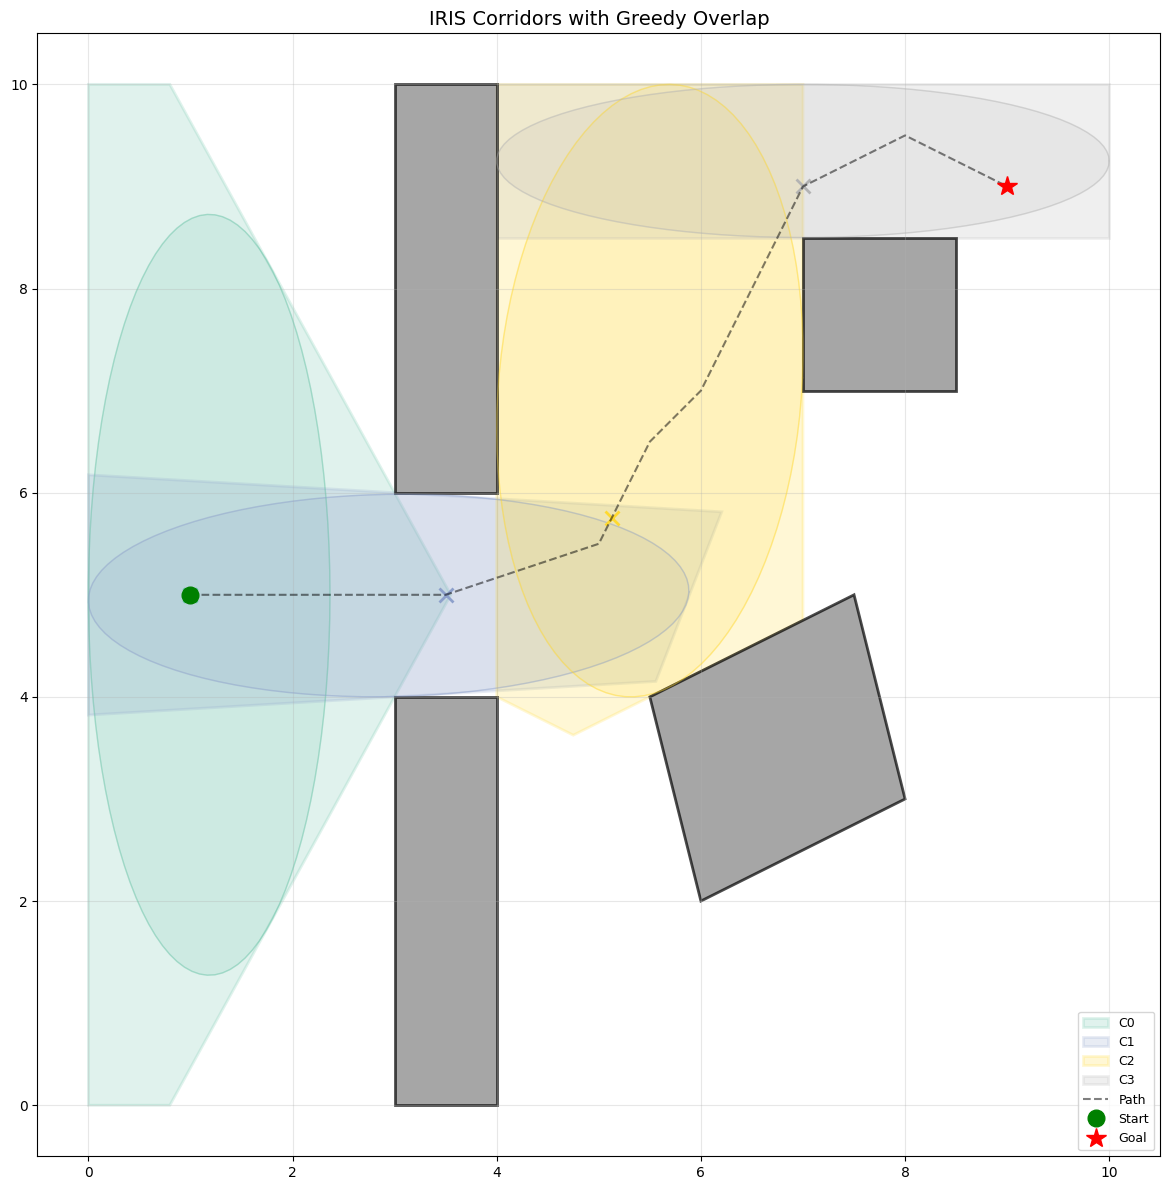

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from scipy.spatial import HalfspaceIntersection, ConvexHull


def hpoly_to_vertices(A, b, interior_point):
    halfspaces = np.column_stack([A, -b])
    try:
        hs = HalfspaceIntersection(halfspaces, interior_point)
        hull = ConvexHull(hs.intersections)
        return hs.intersections[hull.vertices]
    except Exception:
        return None


def plot_ellipsoid(ax, C, d, color='blue', alpha=0.15):
    theta = np.linspace(0, 2 * np.pi, 100)
    circle = np.stack([np.cos(theta), np.sin(theta)], axis=1)
    ellipse = (C @ circle.T).T + d
    ax.fill(ellipse[:, 0], ellipse[:, 1], color=color, alpha=alpha)
    ax.plot(ellipse[:, 0], ellipse[:, 1], color=color, alpha=0.4, lw=1)


def main():
    lower = np.array([0.0, 0.0])
    upper = np.array([10.0, 10.0])
    bounds = (lower, upper)

    obstacles = [
        ConvexObstacle(np.array([[3., 0.], [4., 0.], [4., 4.], [3., 4.]])),
        ConvexObstacle(np.array([[3., 6.], [4., 6.], [4., 10.], [3., 10.]])),
        ConvexObstacle(np.array([[6., 2.], [8., 3.], [7.5, 5.], [5.5, 4.]])),
        ConvexObstacle(np.array([[7., 7.], [8.5, 7.], [8.5, 8.5], [7., 8.5]])),
    ]

    # RRT* path waypoints
    waypoints = np.array([
        [1., 5.], [2., 5.], [3.5, 5.], [5., 5.5],
        [5.5, 6.5], [6., 7.], [6.5, 8.], [7., 9.],
        [8., 9.5], [9., 9.],
    ])

    # Densify
    path = []
    for i in range(len(waypoints) - 1):
        for t in np.linspace(0, 1, 8, endpoint=(i == len(waypoints) - 2)):
            path.append(waypoints[i] * (1 - t) + waypoints[i + 1] * t)
    path = np.array(path)

    print(f"Path: {len(path)} points")
    corridors = greedy_corridor_generation(path, obstacles, bounds)
    print(f"Generated {len(corridors)} corridors")
    verify_corridors(corridors, path)

    # Print H-representations
    for i, c in enumerate(corridors):
        print(f"\nCorridor {i}: seed={c.seed.round(2)}, "
              f"center={c.ellipsoid.d.round(2)}, "
              f"A shape={c.hpoly.A.shape}, "
              f"vol={c.ellipsoid.volume:.3f}")

    # === Plot ===
    fig, ax = plt.subplots(figsize=(12, 12))
    colors = plt.cm.Set2(np.linspace(0, 1, max(len(corridors), 1)))

    for i, cor in enumerate(corridors):
        verts = hpoly_to_vertices(cor.hpoly.A, cor.hpoly.b, cor.ellipsoid.d)
        if verts is not None:
            ax.add_patch(MplPolygon(verts, closed=True,
                                     fc=colors[i], ec=colors[i],
                                     alpha=0.2, lw=2,
                                     label=f'C{i}'))
        plot_ellipsoid(ax, cor.ellipsoid.C, cor.ellipsoid.d, colors[i])
        ax.plot(*cor.seed, 'x', color=colors[i], ms=10, mew=2)

    for obs in obstacles:
        ax.add_patch(MplPolygon(obs.vertices, closed=True,
                                 fc='gray', ec='black', alpha=0.7, lw=2))

    ax.plot(path[:, 0], path[:, 1], 'k--', lw=1.5, alpha=0.5, label='Path')
    ax.plot(*path[0], 'go', ms=12, label='Start', zorder=5)
    ax.plot(*path[-1], 'r*', ms=15, label='Goal', zorder=5)

    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(-0.5, 10.5)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower right', fontsize=9)
    ax.set_title('IRIS Corridors with Greedy Overlap', fontsize=14)
    plt.tight_layout()
    # plt.savefig('/home/claude/iris_corridors.png', dpi=150, bbox_inches='tight')
    print("\nSaved: iris_corridors.png")


if __name__ == '__main__':
    main()
